In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

In [ ]:
data = pd.read_csv("credit.csv")

In [ ]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
print(data.shape)
print(data.describe())

(95162, 31)
               Time            V1            V2            V3            V4  \
count  95162.000000  95162.000000  95162.000000  95162.000000  95162.000000   
mean   41220.807318     -0.264142     -0.037406      0.676465      0.162307   
std    16579.974524      1.867765      1.662025      1.335794      1.352735   
min        0.000000    -56.407510    -72.715728    -33.680984     -5.172595   
25%    32919.250000     -1.028614     -0.603497      0.178324     -0.716021   
50%    43264.500000     -0.260319      0.074743      0.756464      0.188995   
75%    54272.750000      1.153098      0.732010      1.380144      1.032434   
max    65191.000000      1.960497     18.902453      4.226108     16.715537   

                 V5            V6            V7            V8            V9  \
count  95162.000000  95162.000000  95162.000000  95162.000000  95162.000000   
mean      -0.279595      0.093487     -0.107723      0.055063     -0.038993   
std        1.365154      1.302887      

In [ ]:
fraud = data[data['Class'] == 1]
valid = data[data['Class'] == 0]
outlierFraction = len(fraud)/float(len(valid))
print(outlierFraction)
print('Fraud Cases: {}'.format(len(data[data['Class'] == 1])))
print('Valid Transactions: {}'.format(len(data[data['Class'] == 0])))

0.0022855578024941017
Fraud Cases: 217
Valid Transactions: 94944


In [ ]:
print('Amount details of the fraudulent transaction')
fraud.Amount.describe()


Amount details of the fraudulent transaction


count     217.000000
mean      109.784286
std       243.927116
min         0.000000
25%         1.000000
50%         7.580000
75%        99.990000
max      1809.680000
Name: Amount, dtype: float64

In [ ]:
print('details of valid transaction')
valid.Amount.describe()


details of valid transaction


count    94944.000000
mean        98.685374
std        267.432993
min          0.000000
25%          7.600000
50%         26.720000
75%         89.752500
max      19656.530000
Name: Amount, dtype: float64

In [ ]:
# Correlation matrix
corrmat = data.corr()
fig = plt.figure(figsize = (12, 9))
sns.heatmap(corrmat, vmax = .10, square = True)
plt.show()


NameError: name 'data' is not defined

In [ ]:
# dividing the X and the Y from the dataset
X = data.drop(['Class'], axis = 1)
Y = data["Class"]
print(X.shape)
print(Y.shape)
# getting just the values for the sake of processing
# (its a numpy array with no columns)
xData = X.values
yData = Y.values


(95162, 30)
(95162,)


In [ ]:
# Using Scikit-learn to split data into training and testing sets
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
xTrain, xTest, yTrain, yTest = train_test_split(
        xData, yData, test_size = 0.2, random_state = 42)


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

# Remove samples with NaN values in yTrain
mask = ~np.isnan(yTrain)
xTrain_filtered = xTrain[mask]
yTrain_filtered = yTrain[mask]

# Impute missing values in the training data
imputer = SimpleImputer(strategy='mean')  # or 'median', 'most_frequent', 'constant'
xTrain_imputed = imputer.fit_transform(xTrain_filtered)
xTest_imputed = imputer.transform(xTest)

# Create and fit the RandomForestClassifier
rfc = RandomForestClassifier()
rfc.fit(xTrain_imputed, yTrain_filtered)

# Predictions
yPred = rfc.predict(xTest_imputed)



In [ ]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, matthews_corrcoef
from sklearn.metrics import confusion_matrix

# Remove samples with NaN values in yTest
mask = ~np.isnan(yTest)
yTest_filtered = yTest[mask]
yPred_filtered = yPred[mask]

print("The model used is Random Forest classifier")

acc = accuracy_score(yTest_filtered, yPred_filtered)
print("The accuracy is {}".format(acc))

prec = precision_score(yTest_filtered, yPred_filtered)
print("The precision is {}".format(prec))

rec = recall_score(yTest_filtered, yPred_filtered)
print("The recall is {}".format(rec))

f1 = f1_score(yTest_filtered, yPred_filtered)
print("The F1-Score is {}".format(f1))

MCC = matthews_corrcoef(yTest_filtered, yPred_filtered)
print("The Matthews correlation coefficient is {}".format(MCC))


The model used is Random Forest classifier
The accuracy is 0.9993694829760403
The precision is 0.9473684210526315
The recall is 0.782608695652174
The F1-Score is 0.8571428571428571
The Matthews correlation coefficient is 0.86075954470924


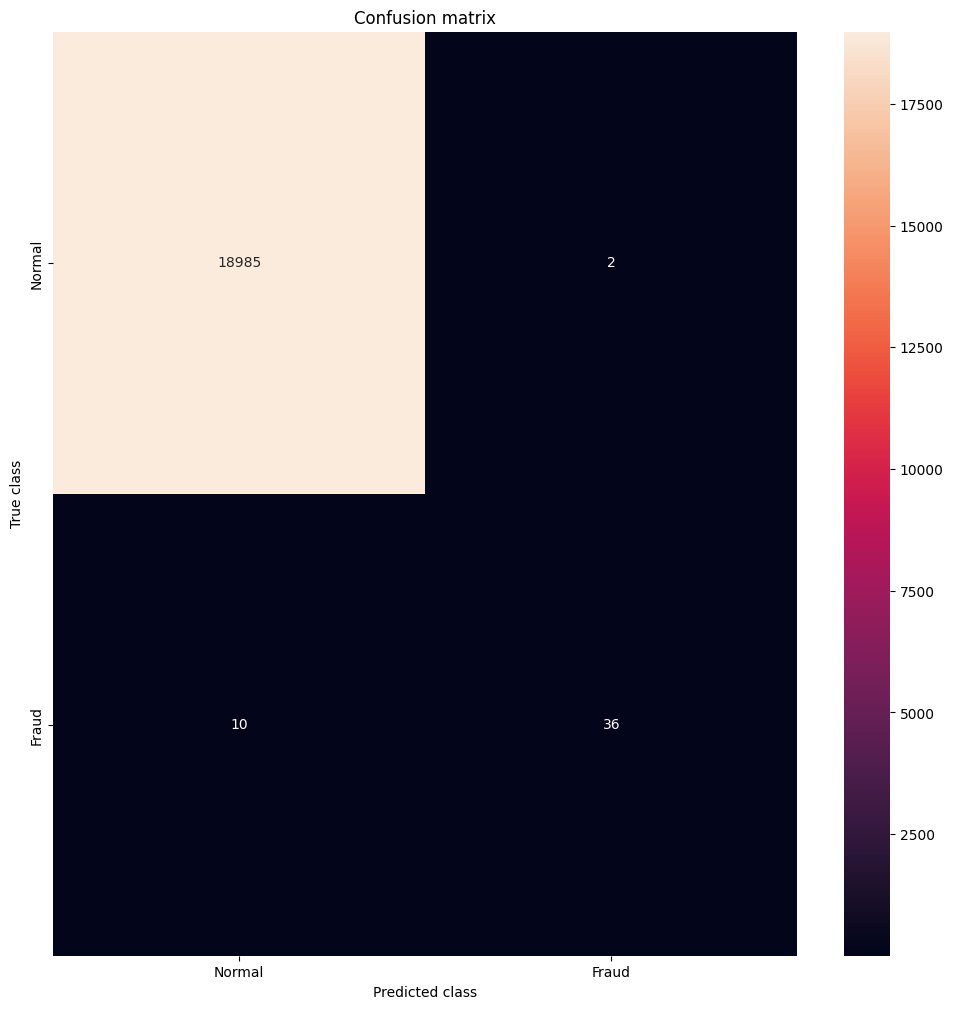

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix

# Impute missing values in yTest
imputer = SimpleImputer(strategy='most_frequent')  # or 'mean', 'median', 'constant'
yTest_imputed = imputer.fit_transform(yTest.reshape(-1, 1)).ravel()

# Compute confusion matrix
conf_matrix = confusion_matrix(yTest_imputed, yPred)
LABELS = ['Normal', 'Fraud']

# Plot the confusion matrix
plt.figure(figsize=(12, 12))
sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d")
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()


